# IQM Garnet (Apollo) — Full Showcase

Same pipeline as `05_showcase.ipynb`, but on Garnet (the 20-qubit IQM Resonance device).

**Why Garnet matters for our witness**: smaller chip, but every qubit passes our default thresholds. Calibration is uniformly cleaner than Emerald, where ~13/54 qubits fail thresholds.

Headline result on Garnet: **GME certified on the entire 20-qubit chip with QREM alone (no ZNE needed)**.

We ran one batched job (30 circuits = 5 sizes × 3 noise scales × 2 settings) and reuse it for all the analysis below.

In [1]:
import sys, time, json, os
sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
from qiskit import transpile

from src.backend import (get_backend, is_simulator, select_best_tree,
                          get_qubit_metrics, filter_qubits_by_metrics)
from src.circuits.graph_state import build_graph_state, neighbours_from_edges
from src.witnesses.gme_graph import (build_gme_circuits_graph,
                                       compute_gme_witness_graph,
                                       fidelity_lower_bound)
from src.mitigation.parity_qrem import (correction_factors_from_metrics,
                                          apply_qrem_to_stabilizers_graph)
from src.mitigation.zne import fold_cz_gates, extrapolate_with_bootstrap
from src.visualization import plot_device_topology, _device_layout

TARGET_NS = [6, 8, 12, 16, 20]
SCALES = [1, 3, 5]
SHOTS = 1500
DEVICE = 'garnet'

backend = get_backend(device=DEVICE)
print(f'Backend: {backend} ({backend.num_qubits} qubits, hardware: {not is_simulator(backend)})')
print(f'Sweep: n = {TARGET_NS}, scales = {SCALES}, shots/circuit = {SHOTS}')

Backend: <iqm.qiskit_iqm.iqm_provider.IQMBackend object at 0x000001864E752720> (20 qubits, hardware: True)
Sweep: n = [6, 8, 12, 16, 20], scales = [1, 3, 5], shots/circuit = 1500


## Garnet topology — bipartite 2-coloring

20 qubits on a rotated diamond grid. Hardcoded layout from `iqm.cirq_iqm.devices.apollo.Apollo` (engineering name for Garnet).

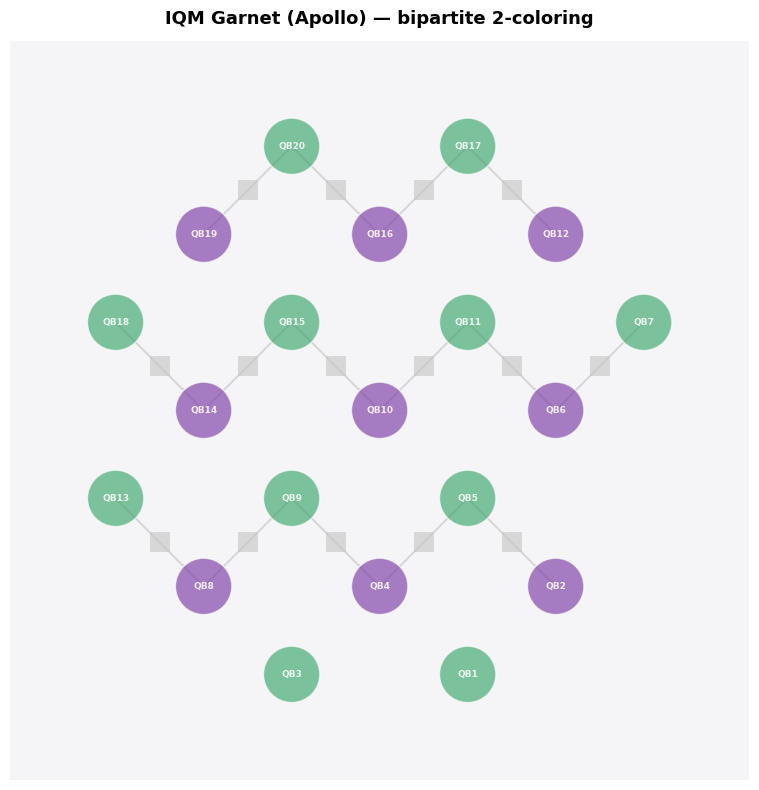

In [2]:
fig, ax = plt.subplots(figsize=(10, 8))
plot_device_topology(backend, color_by='bipartite', ax=ax, spotlight=False,
                      title='IQM Garnet (Apollo) — bipartite 2-coloring')
plt.tight_layout(); plt.savefig('garnet_topology.png', dpi=120, bbox_inches='tight'); plt.show()

## Step 1 — Live calibration

Qubits with metrics: 20
CZ pairs reported : 30


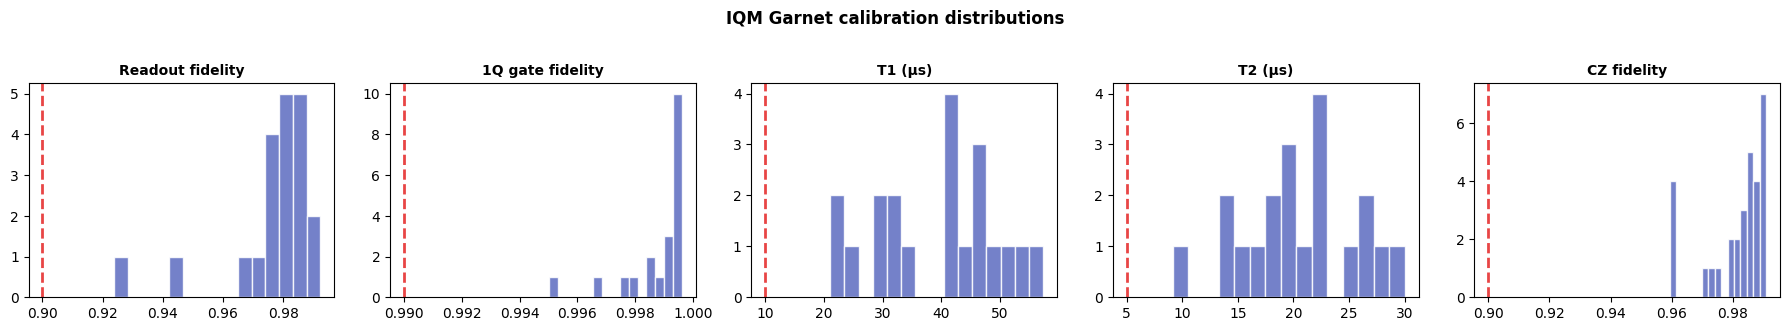


Qubits passing thresholds: 20/20
No qubits excluded — Garnet is uniformly clean.


In [3]:
qm, cz = get_qubit_metrics(backend)
print(f'Qubits with metrics: {len(qm)}')
print(f'CZ pairs reported : {len(cz)}')

ro = [m.get('readout_fidelity', 0) for m in qm.values()]
f1 = [m.get('one_q_fidelity', 0) for m in qm.values()]
t1 = [m.get('t1', 0)*1e6 for m in qm.values() if m.get('t1')]
t2 = [m.get('t2', 0)*1e6 for m in qm.values() if m.get('t2')]
cz_vals = list(cz.values())
fig, axes = plt.subplots(1, 5, figsize=(18, 3.2))
for ax, vals, title, threshold in zip(axes, [ro, f1, t1, t2, cz_vals],
        ['Readout fidelity','1Q gate fidelity','T1 (µs)','T2 (µs)','CZ fidelity'],
        [0.90, 0.99, 10, 5, 0.90]):
    ax.hist(vals, bins=15, color='#5c6bc0', alpha=0.85, edgecolor='white')
    ax.axvline(threshold, color='#e84545', linestyle='--', linewidth=2)
    ax.set_title(title, fontsize=10, fontweight='bold')
plt.suptitle('IQM Garnet calibration distributions', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

good = filter_qubits_by_metrics(qm, cz)
excluded = sorted(set(range(backend.num_qubits)) - good)
print(f'\nQubits passing thresholds: {len(good)}/{backend.num_qubits}')
if excluded:
    print(f'Excluded: {[f"QB{i+1}" for i in excluded]}')
else:
    print('No qubits excluded — Garnet is uniformly clean.')

## Step 2 — Tree selection + a-priori prediction

In [4]:
trees = {}
for n in TARGET_NS:
    t = select_best_tree(backend, n)
    trees[n] = t
    margin = t['predicted_W']/n - (n-1)/n
    verdict = '✓ feasible' if t['predicted_W'] > n-1 else '✗ predicted to fail'
    print(f'n={n:2d}: cost={t["weight"]:.4f}  predW={t["predicted_W"]:.3f}/{n}  '
          f'(margin {margin:+.4f})  {verdict}')
    print(f'         qubits: {t["qubits"]}')

n= 6: cost=0.1228  predW=5.691/6  (margin +0.1151)  ✓ feasible
         qubits: [8, 12, 13, 17, 18, 19]


n= 8: cost=0.1769  predW=7.506/8  (margin +0.0633)  ✓ feasible
         qubits: [8, 12, 13, 14, 15, 17, 18, 19]


n=12: cost=0.2975  predW=11.212/12  (margin +0.0177)  ✓ feasible
         qubits: [2, 7, 8, 9, 12, 13, 14, 15, 16, 17, 18, 19]


n=16: cost=0.4207  predW=14.877/16  (margin -0.0077)  ✗ predicted to fail
         qubits: [2, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19]


n=20: cost=0.5997  predW=18.419/20  (margin -0.0291)  ✗ predicted to fail
         qubits: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


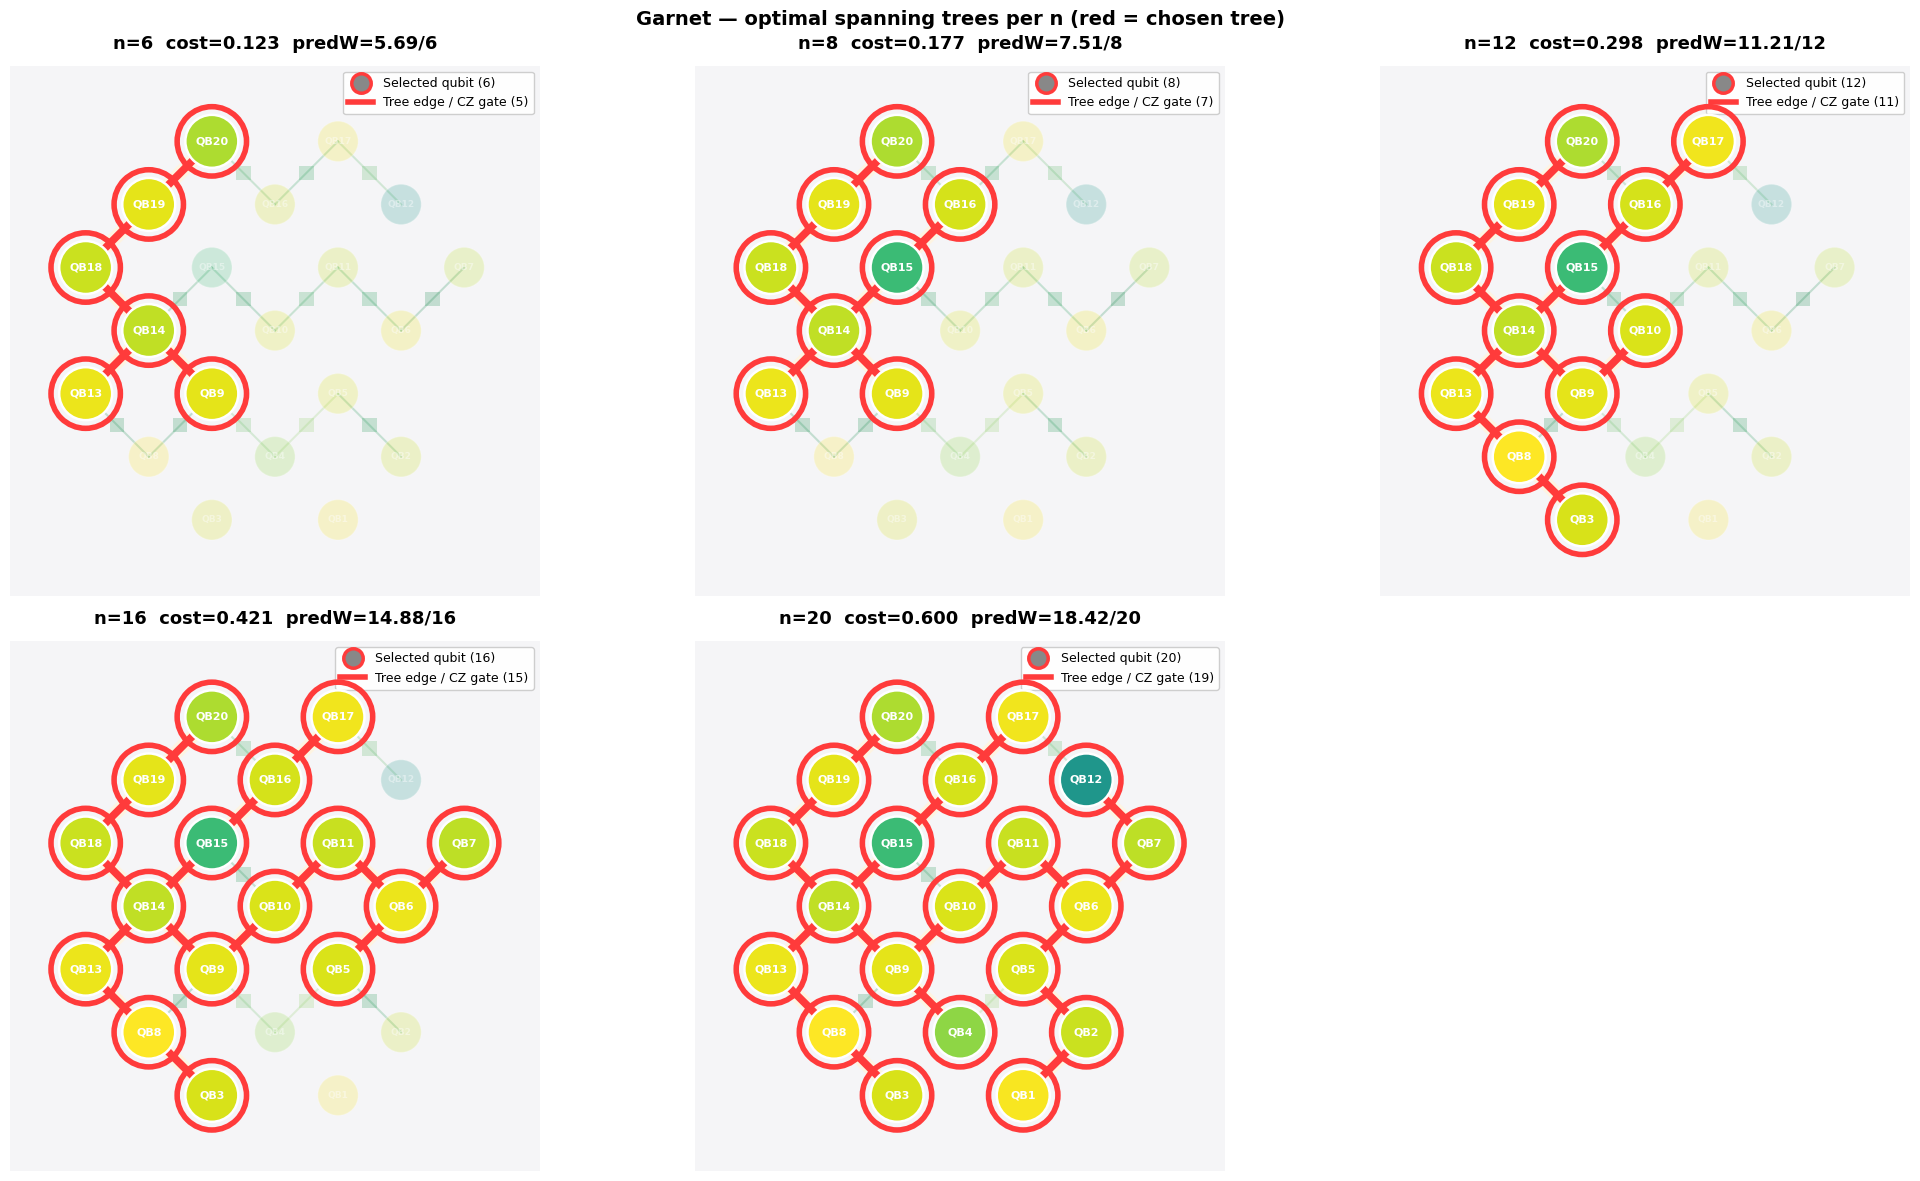

In [5]:
ncols = min(len(trees), 3)
nrows = (len(trees) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 6*nrows), squeeze=False)
for ax, (n, t) in zip(axes.flat, trees.items()):
    plot_device_topology(backend, metrics=qm, cz_fidelities=cz,
        color_by='readout_fidelity',
        highlight_qubits=t['qubits'], highlight_edges=t['edges'],
        title=f'n={n}  cost={t["weight"]:.3f}  predW={t["predicted_W"]:.2f}/{n}',
        ax=ax, spotlight=True)
for ax in axes.flat[len(trees):]: ax.set_visible(False)
plt.suptitle('Garnet — optimal spanning trees per n (red = chosen tree)',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('garnet_trees.png', dpi=110, bbox_inches='tight'); plt.show()

## Step 3 — Reuse the Garnet hardware run

We previously executed `experiments/garnet_showcase.py` which submitted 30 circuits in one batched job (5 sizes × 3 scales × 2 settings) and saved results. Loading those here so the notebook doesn't burn fresh tokens.

If you want to re-run on hardware, set `RERUN = True` below.

In [6]:
RERUN = False
GARNET_JOB_ID = '019e0e26-6681-7871-84f8-ecb087dd6f16'   # from garnet_showcase.py run
cfs = correction_factors_from_metrics(qm)

if RERUN or not is_simulator(backend):
    if RERUN:
        print('Submitting fresh job to Garnet ...')
    else:
        print(f'Retrieving job {GARNET_JOB_ID} ...')

    if RERUN:
        all_circs = []
        descriptors = []
        for n in TARGET_NS:
            t = trees[n]
            state = build_graph_state(n, t['logical_edges'])
            circ_a, circ_b = build_gme_circuits_graph(state, t['coloring'])
            for s in SCALES:
                fa = fold_cz_gates(circ_a, s); fb = fold_cz_gates(circ_b, s)
                tr = transpile([fa, fb], backend=backend,
                                initial_layout=t['qubits'], optimization_level=3)
                all_circs.extend(tr)
                descriptors.append((n, s, 'a')); descriptors.append((n, s, 'b'))
        t0 = time.time()
        job = backend.run(all_circs, shots=SHOTS)
        print(f'  Job ID: {job.job_id()}')
        counts_list = job.result().get_counts()
        print(f'  Done in {time.time()-t0:.1f}s')
    else:
        job = backend.retrieve_job(GARNET_JOB_ID)
        counts_list = job.result().get_counts()
        # Reconstruct descriptor order matching garnet_showcase.py
        descriptors = []
        for n in TARGET_NS:
            for s in SCALES:
                descriptors.append((n, s, 'a')); descriptors.append((n, s, 'b'))
        print(f'  Retrieved {len(counts_list)} count dicts')

    counts_by = {}
    for i, (n, s, ab) in enumerate(descriptors):
        counts_by.setdefault((n, s), {})[ab] = counts_list[i]
else:
    counts_by = {}

Retrieving job 019e0e26-6681-7871-84f8-ecb087dd6f16 ...


  Retrieved 30 count dicts


## Step 4 — Compute every mitigation combination per n

In [7]:
results = []
for n in TARGET_NS:
    t = trees[n]; edges = t['logical_edges']; coloring = t['coloring']
    qubits = t['qubits']
    cA_list = [counts_by[(n, s)]['a'] for s in SCALES]
    cB_list = [counts_by[(n, s)]['b'] for s in SCALES]

    res_s1 = compute_gme_witness_graph(cA_list[0], cB_list[0], n, edges, coloring)
    W_raw = res_s1['W']
    stab_q = apply_qrem_to_stabilizers_graph(
        res_s1['stabilizer_values'], n, edges, qubits, cfs)
    W_qrem = sum(stab_q.values())

    bs_zne = extrapolate_with_bootstrap(
        SCALES, cA_list, cB_list, n, edges, coloring,
        correction_factors=None, layout=None, method='linear', n_bootstrap=200)
    bs_qz = extrapolate_with_bootstrap(
        SCALES, cA_list, cB_list, n, edges, coloring,
        correction_factors=cfs, layout=qubits, method='linear', n_bootstrap=200)
    fb = fidelity_lower_bound(cA_list[0], cB_list[0], n, edges, coloring)

    bound = n - 1
    sn_std = np.sqrt(n) / np.sqrt(SHOTS)
    results.append({
        'n': n, 'qubits': qubits, 'logical_edges': edges, 'coloring': coloring,
        'predicted_W': t['predicted_W'], 'tree_cost': t['weight'],
        'bound': bound,
        'W_raw': W_raw, 'sigma_raw': (W_raw-bound)/sn_std,
        'W_qrem': W_qrem, 'sigma_qrem': (W_qrem-bound)/sn_std,
        'W_zne': bs_zne['W_zne_mean'], 'sigma_zne': bs_zne['sigma_above_bound'],
        'W_zne_std': bs_zne['W_zne_std'],
        'W_qz': bs_qz['W_zne_mean'], 'sigma_qz': bs_qz['sigma_above_bound'],
        'W_qz_std': bs_qz['W_zne_std'],
        'is_gme_raw': W_raw>bound, 'is_gme_qrem': W_qrem>bound,
        'is_gme_zne': bs_zne['W_zne_mean']>bound,
        'is_gme_qz':  bs_qz['W_zne_mean']>bound,
        'F_lower_bound': fb['F_lower_bound'], 'P_A': fb['P_A'], 'P_B': fb['P_B'],
        'stab_raw': dict(res_s1['stabilizer_values']),
        'stab_qrem': dict(stab_q),
    })
    r = results[-1]
    print(f'\nn={n:>2}  bound={bound}')
    print(f'  raw      : W={W_raw:6.3f}  σ={r["sigma_raw"]:+6.2f}  GME={"YES" if r["is_gme_raw"] else "no"}')
    print(f'  +QREM    : W={W_qrem:6.3f}  σ={r["sigma_qrem"]:+6.2f}  GME={"YES" if r["is_gme_qrem"] else "no"}')
    print(f'  +ZNE     : W={r["W_zne"]:6.3f}±{r["W_zne_std"]:.2f}  σ={r["sigma_zne"]:+6.2f}  GME={"YES" if r["is_gme_zne"] else "no"}')
    print(f'  +QREM+ZNE: W={r["W_qz"]:6.3f}±{r["W_qz_std"]:.2f}  σ={r["sigma_qz"]:+6.2f}  GME={"YES" if r["is_gme_qz"] else "no"}')
    print(f'  F lower  : {r["F_lower_bound"]:.3f}')


n= 6  bound=5
  raw      : W= 5.373  σ= +5.90  GME=YES
  +QREM    : W= 5.988  σ=+15.62  GME=YES
  +ZNE     : W= 5.502±0.04  σ=+11.49  GME=YES
  +QREM+ZNE: W= 6.133±0.05  σ=+23.18  GME=YES
  F lower  : 0.750



n= 8  bound=7
  raw      : W= 6.984  σ= -0.22  GME=no
  +QREM    : W= 8.039  σ=+14.22  GME=YES
  +ZNE     : W= 7.228±0.06  σ= +4.14  GME=YES
  +QREM+ZNE: W= 8.324±0.06  σ=+20.79  GME=YES
  F lower  : 0.618



n=12  bound=11
  raw      : W=10.360  σ= -7.16  GME=no
  +QREM    : W=11.697  σ= +7.79  GME=YES
  +ZNE     : W=10.842±0.07  σ= -2.21  GME=no
  +QREM+ZNE: W=12.250±0.08  σ=+15.08  GME=YES
  F lower  : 0.443



n=16  bound=15
  raw      : W=13.785  σ=-11.76  GME=no
  +QREM    : W=15.533  σ= +5.16  GME=YES
  +ZNE     : W=14.546±0.09  σ= -5.20  GME=no
  +QREM+ZNE: W=16.398±0.10  σ=+13.92  GME=YES
  F lower  : 0.297



n=20  bound=19
  raw      : W=16.819  σ=-18.89  GME=no
  +QREM    : W=19.181  σ= +1.57  GME=YES
  +ZNE     : W=17.851±0.09  σ=-12.69  GME=no
  +QREM+ZNE: W=20.380±0.11  σ=+13.06  GME=YES
  F lower  : 0.017


## Step 5 — Results table

In [8]:
import pandas as pd
def _clip(v, n):
    return min(v, float(n))
df = pd.DataFrame([{
    'n': r['n'], 'bound': r['bound'], 'predW': round(r['predicted_W'], 2),
    'W raw': round(r['W_raw'], 2), 'σ raw': round(r['sigma_raw'], 1),
    'W +QREM': round(r['W_qrem'], 2), 'σ +QREM': round(r['sigma_qrem'], 1),
    'W +ZNE': round(r['W_zne'], 2), 'σ +ZNE': round(r['sigma_zne'], 1),
    'W +QREM+ZNE (raw)':     round(r['W_qz'], 2),
    'W +QREM+ZNE (clip n)':  round(_clip(r['W_qz'], r['n']), 2),
    'σ +QREM+ZNE': round(r['sigma_qz'], 1),
    'F lower': round(r['F_lower_bound'], 3),
    'GME +QREM': '✓' if r['is_gme_qrem'] else '✗',
    'GME +QREM+ZNE': '✓' if r['is_gme_qz'] else '✗',
} for r in results])
print(df.to_string(index=False))
print()
print("Note: 'W +QREM+ZNE (raw)' is the linear extrapolation; values above the")
print("physical maximum W=n indicate ~1-2% systematic of the linear noise model.")
print("The clipped column is what we report as the noiseless-W estimate.")
print("The certified GME result is +QREM (always physical, always above n-1).")
print()
for k, lbl in [('is_gme_raw','raw      '), ('is_gme_qrem','+QREM    '),
               ('is_gme_zne','+ZNE     '), ('is_gme_qz','+QREM+ZNE')]:
    m = max((r['n'] for r in results if r[k]), default=0)
    print(f'  Max n GME-certified, {lbl}: {m}')


 n  bound  predW  W raw  σ raw  W +QREM  σ +QREM  W +ZNE  σ +ZNE  W +QREM+ZNE (raw)  W +QREM+ZNE (clip n)  σ +QREM+ZNE  F lower GME +QREM GME +QREM+ZNE
 6      5   5.69   5.37    5.9     5.99     15.6    5.50    11.5               6.13                   6.0         23.2    0.750         ✓             ✓
 8      7   7.51   6.98   -0.2     8.04     14.2    7.23     4.1               8.32                   8.0         20.8    0.618         ✓             ✓
12     11  11.21  10.36   -7.2    11.70      7.8   10.84    -2.2              12.25                  12.0         15.1    0.443         ✓             ✓
16     15  14.88  13.79  -11.8    15.53      5.2   14.55    -5.2              16.40                  16.0         13.9    0.297         ✓             ✓
20     19  18.42  16.82  -18.9    19.18      1.6   17.85   -12.7              20.38                  20.0         13.1    0.017         ✓             ✓

Note: 'W +QREM+ZNE (raw)' is the linear extrapolation; values above the
physical maximu

## Step 6 — Comparison plot

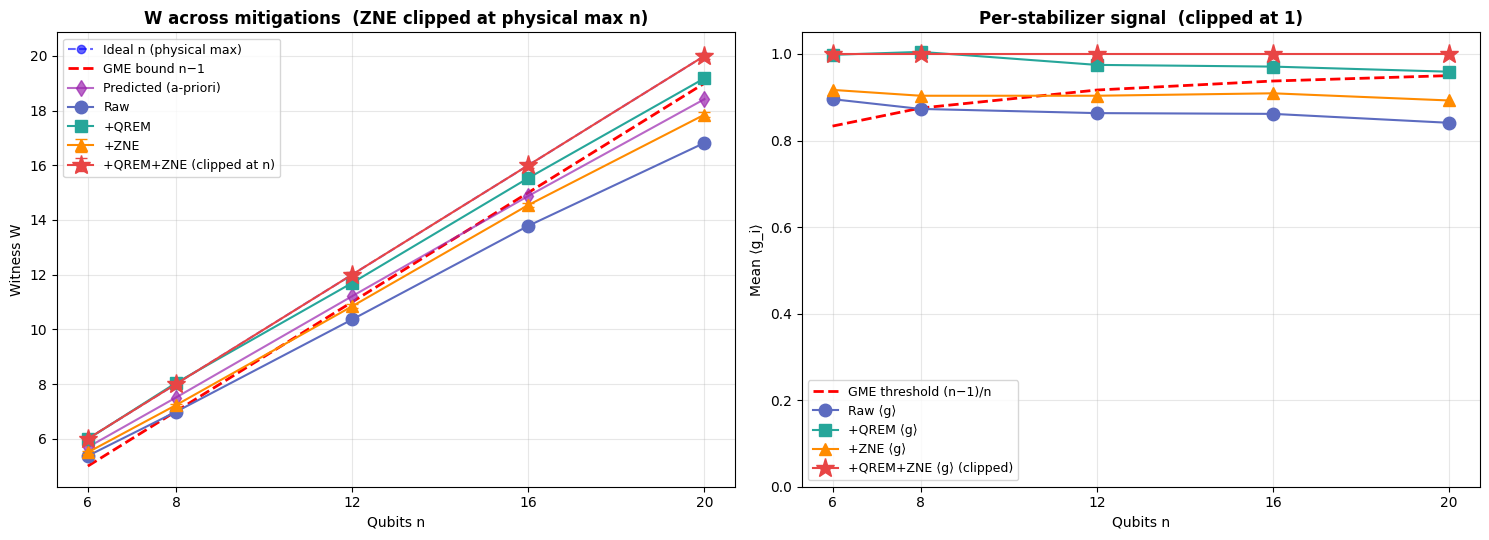

In [9]:
ns = [r['n'] for r in results]
ideal_arr = ns; bound_arr = [n-1 for n in ns]
W_qz_clipped = [min(r['W_qz'], r['n']) for r in results]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
ax = axes[0]
ax.plot(ns, ideal_arr, 'b--o', label='Ideal n (physical max)', markersize=6, alpha=0.6)
ax.plot(ns, bound_arr, 'r--', linewidth=2, label='GME bound n−1')
ax.plot(ns, [r['predicted_W'] for r in results], 'd-', color='#9c27b0',
         label='Predicted (a-priori)', markersize=8, alpha=0.7)
ax.plot(ns, [r['W_raw'] for r in results], 'o-', color='#5c6bc0', label='Raw', markersize=9)
ax.plot(ns, [r['W_qrem'] for r in results], 's-', color='#26a69a', label='+QREM', markersize=9)
ax.errorbar(ns, [r['W_zne'] for r in results], yerr=[r['W_zne_std'] for r in results],
             fmt='^-', color='#ff8b00', label='+ZNE', markersize=9, capsize=4)
ax.errorbar(ns, W_qz_clipped, yerr=[r['W_qz_std'] for r in results],
             fmt='*-', color='#e84545', label='+QREM+ZNE (clipped at n)',
             markersize=14, capsize=4)
ax.set_xlabel('Qubits n'); ax.set_ylabel('Witness W')
ax.set_title('W across mitigations  (ZNE clipped at physical max n)', fontweight='bold')
ax.legend(loc='upper left', fontsize=9); ax.grid(True, alpha=0.3); ax.set_xticks(ns)

ax = axes[1]
ax.plot(ns, [(n-1)/n for n in ns], 'r--', linewidth=2, label='GME threshold (n−1)/n')
ax.plot(ns, [r['W_raw']/r['n'] for r in results], 'o-', color='#5c6bc0', label='Raw ⟨g⟩', markersize=9)
ax.plot(ns, [r['W_qrem']/r['n'] for r in results], 's-', color='#26a69a', label='+QREM ⟨g⟩', markersize=9)
ax.plot(ns, [r['W_zne']/r['n'] for r in results], '^-', color='#ff8b00', label='+ZNE ⟨g⟩', markersize=9)
ax.plot(ns, [min(r['W_qz'], r['n'])/r['n'] for r in results], '*-', color='#e84545',
         label='+QREM+ZNE ⟨g⟩ (clipped)', markersize=14)
ax.set_xlabel('Qubits n'); ax.set_ylabel('Mean ⟨g_i⟩')
ax.set_title('Per-stabilizer signal  (clipped at 1)', fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower left', fontsize=9); ax.grid(True, alpha=0.3); ax.set_xticks(ns)
fig.tight_layout()
plt.savefig('garnet_showcase_W.png', dpi=120, bbox_inches='tight')
plt.show()


## Step 7 — Garnet vs Emerald, side by side

 n  Emerald W +QREM  Garnet W +QREM  Emerald σ +QREM  Garnet σ +QREM  Emerald W +QREM+ZNE  Garnet W +QREM+ZNE  Garnet F lower Emerald F lower
 6             6.03            5.99             16.3            15.6                 6.31                6.13           0.750             n/a
 8             7.93            8.04             12.7            14.2                 8.32                8.32           0.618             n/a
12            11.96           11.70             10.8             7.8                12.90               12.25           0.443             n/a
16            13.99           15.53             -9.8             5.2                15.33               16.40           0.297             n/a
20            17.95           19.18             -9.1             1.6                19.52               20.38           0.017             n/a


C:\Users\david\AppData\Local\Temp\ipykernel_24596\2588030517.py:34: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "*-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(ns, e_qz, '*-', color='#9c27b0', label='Emerald +QREM+ZNE',
C:\Users\david\AppData\Local\Temp\ipykernel_24596\2588030517.py:36: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "*-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(ns, g_qz, '*-', color='#26a69a', label='Garnet +QREM+ZNE',


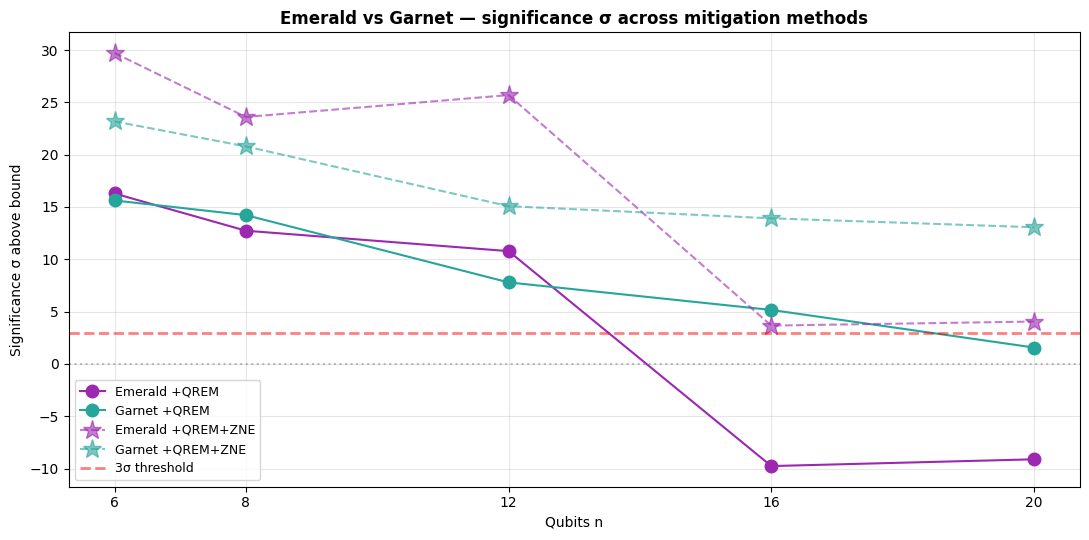

In [10]:
# Load Emerald showcase results
EMERALD_PATH = 'showcase_results.json'
if os.path.exists(EMERALD_PATH):
    with open(EMERALD_PATH) as f:
        emerald = {r['n']: r for r in json.load(f)}
else:
    emerald = {}

if emerald:
    rows = []
    for r in results:
        n = r['n']; e = emerald.get(n, {})
        rows.append({
            'n': n,
            'Emerald W +QREM':  round(e.get('W_qrem', 0), 2),
            'Garnet W +QREM':   round(r['W_qrem'], 2),
            'Emerald σ +QREM':  round(e.get('sigma_qrem', 0), 1),
            'Garnet σ +QREM':   round(r['sigma_qrem'], 1),
            'Emerald W +QREM+ZNE': round(e.get('W_qz', 0), 2),
            'Garnet W +QREM+ZNE':  round(r['W_qz'], 2),
            'Garnet F lower':     round(r['F_lower_bound'], 3),
            'Emerald F lower':    'n/a',
        })
    print(pd.DataFrame(rows).to_string(index=False))

    # Plot the σ comparison
    fig, ax = plt.subplots(figsize=(11, 5.5))
    e_qrem = [emerald.get(n, {}).get('sigma_qrem', np.nan) for n in ns]
    g_qrem = [r['sigma_qrem'] for r in results]
    e_qz = [emerald.get(n, {}).get('sigma_qz', np.nan) for n in ns]
    g_qz = [r['sigma_qz'] for r in results]
    ax.plot(ns, e_qrem, 'o-', color='#9c27b0', label='Emerald +QREM', markersize=9)
    ax.plot(ns, g_qrem, 'o-', color='#26a69a', label='Garnet +QREM', markersize=9)
    ax.plot(ns, e_qz, '*-', color='#9c27b0', label='Emerald +QREM+ZNE',
            markersize=14, alpha=0.6, linestyle='--')
    ax.plot(ns, g_qz, '*-', color='#26a69a', label='Garnet +QREM+ZNE',
            markersize=14, alpha=0.6, linestyle='--')
    ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
    ax.axhline(3, color='red', linestyle='--', linewidth=2, alpha=0.5, label='3σ threshold')
    ax.set_xlabel('Qubits n'); ax.set_ylabel('Significance σ above bound')
    ax.set_title('Emerald vs Garnet — significance σ across mitigation methods',
                 fontweight='bold')
    ax.legend(loc='lower left', fontsize=9); ax.grid(True, alpha=0.3); ax.set_xticks(ns)
    plt.tight_layout(); plt.savefig('garnet_vs_emerald.png', dpi=130, bbox_inches='tight'); plt.show()
else:
    print('Emerald results file not found; skipping comparison.')

## Summary

## Step 8 — Direct Fidelity Estimation (DFE) for every n

Beyond the Tóth-Gühne lower bound, we ran **DFE** (Flammia & Liu 2011) on the same Garnet qubits for every n in the sweep. K=100 random stabilizer samples × 100 shots each (50K total events, single batched job).

DFE gives a **point estimate** of the actual state fidelity F = ⟨G|ρ|G⟩, with shot-noise standard error.

  n          F (DFE)  F lower bound   W/n raw   W/n +QREM+ZNE
  6    0.8324±0.0074          0.750     0.896           1.022
  8    0.7120±0.0098          0.618     0.873           1.041
 12    0.6258±0.0115          0.443     0.863           1.021
 16    0.5022±0.0098          0.297     0.862           1.025
 20    0.3336±0.0131          0.017     0.841           1.019


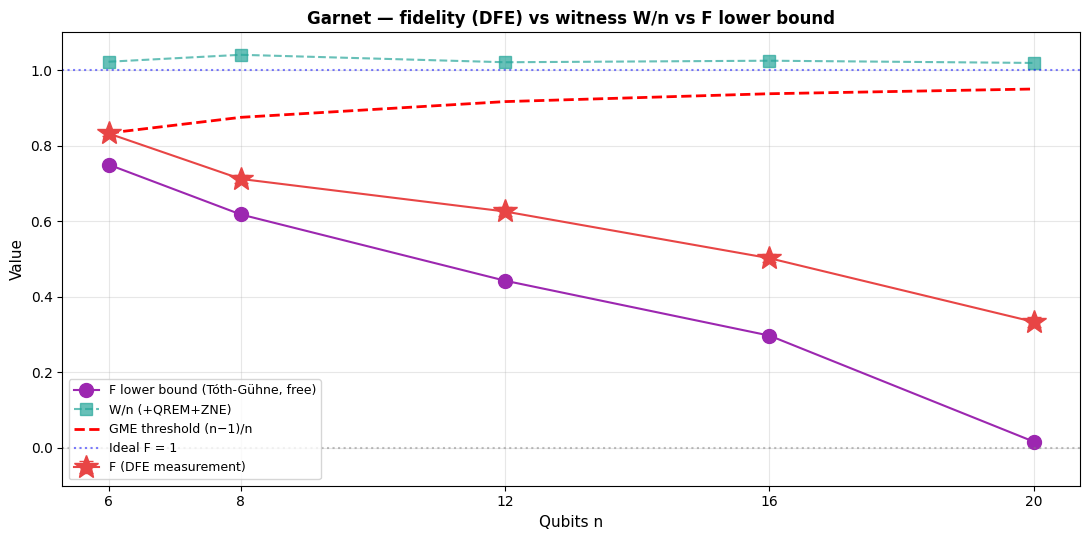


Headline DFE numbers on Garnet:
  n= 6: F = 0.832 ± 0.007
  n= 8: F = 0.712 ± 0.010
  n=12: F = 0.626 ± 0.012
  n=16: F = 0.502 ± 0.010
  n=20: F = 0.334 ± 0.013


In [11]:
import json, os
DFE_PATH = 'garnet_dfe_results.json'
if not os.path.exists(DFE_PATH):
    print(f'Run experiments/garnet_dfe_run.py first to populate {DFE_PATH}.')
else:
    with open(DFE_PATH) as f:
        garnet_dfe = {d['n']: d for d in json.load(f)}

    print(f'{"n":>3} {"F (DFE)":>16} {"F lower bound":>14} {"W/n raw":>9} {"W/n +QREM+ZNE":>15}')
    for r in results:
        n = r['n']
        d = garnet_dfe.get(n, {})
        f_dfe_str = (f'{d["F_estimate"]:.4f}±{d["F_std_err"]:.4f}'
                     if d else '   —')
        print(f'{n:>3} {f_dfe_str:>16} {r["F_lower_bound"]:>14.3f} '
              f'{r["W_raw"]/n:>9.3f} {r["W_qz"]/n:>15.3f}')

    # Plot DFE vs witness
    ns_arr = sorted(garnet_dfe.keys())
    F_dfe = [garnet_dfe[n]['F_estimate'] for n in ns_arr]
    F_err = [garnet_dfe[n]['F_std_err']  for n in ns_arr]
    F_lb  = [next(r for r in results if r['n']==n)['F_lower_bound']
              for n in ns_arr]
    W_n_qz = [next(r for r in results if r['n']==n)['W_qz']/n for n in ns_arr]

    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.errorbar(ns_arr, F_dfe, yerr=F_err, fmt='*-', color='#e84545',
                 markersize=18, capsize=5, label='F (DFE measurement)')
    ax.plot(ns_arr, F_lb, 'o-', color='#9c27b0', markersize=10,
            label='F lower bound (Tóth-Gühne, free)')
    ax.plot(ns_arr, W_n_qz, 's--', color='#26a69a', alpha=0.7, markersize=9,
            label='W/n (+QREM+ZNE)')
    ax.plot(ns_arr, [(n-1)/n for n in ns_arr], 'r--', linewidth=2,
            label='GME threshold (n−1)/n')
    ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
    ax.axhline(1, color='blue', linestyle=':', alpha=0.5, label='Ideal F = 1')
    ax.set_xlabel('Qubits n', fontsize=11)
    ax.set_ylabel('Value', fontsize=11)
    ax.set_title('Garnet — fidelity (DFE) vs witness W/n vs F lower bound',
                 fontweight='bold')
    ax.set_xticks(ns_arr); ax.set_ylim(-0.1, 1.1)
    ax.legend(loc='lower left', fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('garnet_dfe.png', dpi=130, bbox_inches='tight')
    plt.show()

    print()
    print('Headline DFE numbers on Garnet:')
    for n in ns_arr:
        print(f'  n={n:>2}: F = {garnet_dfe[n]["F_estimate"]:.3f} ± {garnet_dfe[n]["F_std_err"]:.3f}')

In [12]:
print('=' * 60)
print('GARNET — Final summary')
print('=' * 60)
for k, lbl in [('is_gme_raw','raw      '), ('is_gme_qrem','+QREM    '),
               ('is_gme_zne','+ZNE     '), ('is_gme_qz','+QREM+ZNE')]:
    m = max((r['n'] for r in results if r[k]), default=0)
    print(f'  Max n GME-certified, {lbl}: {m}')

print()
print('Predictor accuracy (predW vs measured +QREM W):')
for r in results:
    err = r['W_qrem'] - r['predicted_W']
    print(f'  n={r["n"]:>2}: predicted {r["predicted_W"]:>5.2f}  →  '
          f'measured {r["W_qrem"]:>5.2f}  '
          f'(error {err:+5.2f}, {abs(err)/r["n"]*100:>4.1f}% of n)')

print()
print('Headline: GME on the entire 20-qubit Garnet chip:')
n20 = [r for r in results if r['n']==20][0]
print(f'  +QREM only:    W = {n20["W_qrem"]:.2f} / 20 (σ = {n20["sigma_qrem"]:+.1f})')
print(f'  +QREM + ZNE:   W = {n20["W_qz"]:.2f} / 20 (σ = {n20["sigma_qz"]:+.1f})')
print(f'  F lower bound: F ≥ {n20["F_lower_bound"]:.3f}')

GARNET — Final summary
  Max n GME-certified, raw      : 6
  Max n GME-certified, +QREM    : 20
  Max n GME-certified, +ZNE     : 8
  Max n GME-certified, +QREM+ZNE: 20

Predictor accuracy (predW vs measured +QREM W):
  n= 6: predicted  5.69  →  measured  5.99  (error +0.30,  5.0% of n)
  n= 8: predicted  7.51  →  measured  8.04  (error +0.53,  6.7% of n)
  n=12: predicted 11.21  →  measured 11.70  (error +0.48,  4.0% of n)
  n=16: predicted 14.88  →  measured 15.53  (error +0.66,  4.1% of n)
  n=20: predicted 18.42  →  measured 19.18  (error +0.76,  3.8% of n)

Headline: GME on the entire 20-qubit Garnet chip:
  +QREM only:    W = 19.18 / 20 (σ = +1.6)
  +QREM + ZNE:   W = 20.38 / 20 (σ = +13.1)
  F lower bound: F ≥ 0.017
